# Module 3 â€” Appendiceal Cancer: Adverse Reactions

**Prerequisite:** Run `01_appendiceal_explore.ipynb` first to create the `appendiceal_reports` table.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [41]:
##Open appendiceal cohort table created in 01_appendiceal_explore.ipynb and sort by number of reactions reported for each symptom.
# Query with percentage of drug reports instead of raw counts
# Subquery calculates total reports per drug, then we divide each reaction count by that total


appendiceal_cohort_reactions_pct = pd.read_sql_query("""
    SELECT 
        ac.drugname,
        ac.reaction,
        COUNT(*) AS reports,
        ROUND(100.0 * COUNT(*) / drug_totals.total, 1) AS pct_of_drug_reports
    FROM appendiceal_cohort ac
    JOIN (
        SELECT drugname, COUNT(*) AS total
        FROM appendiceal_cohort
        GROUP BY drugname
        HAVING COUNT(*) >= 20
    ) drug_totals ON ac.drugname = drug_totals.drugname
    GROUP BY ac.drugname, ac.reaction
    HAVING pct_of_drug_reports > 4
    ORDER BY ac.drugname, pct_of_drug_reports DESC
""", conn)



appendiceal_cohort_reactions_pct.head(20)

,drugname,reaction,reports,pct_of_drug_reports
0,BEVACIZUMAB,Deep vein thrombosis,6,10.2
1,BEVACIZUMAB,Streptococcal infection,4,6.8
2,BEVACIZUMAB,Off label use,4,6.8
3,BEVACIZUMAB,Fusobacterium infection,4,6.8
4,BEVACIZUMAB,Brain abscess,4,6.8
5,BEVACIZUMAB,Pulmonary embolism,3,5.1
6,CAPECITABINE,Diarrhoea,12,8.6
7,CAPECITABINE,Gastrointestinal injury,10,7.1
8,CAPECITABINE,Pyrexia,8,5.7
9,CAPECITABINE,Abdominal pain,8,5.7


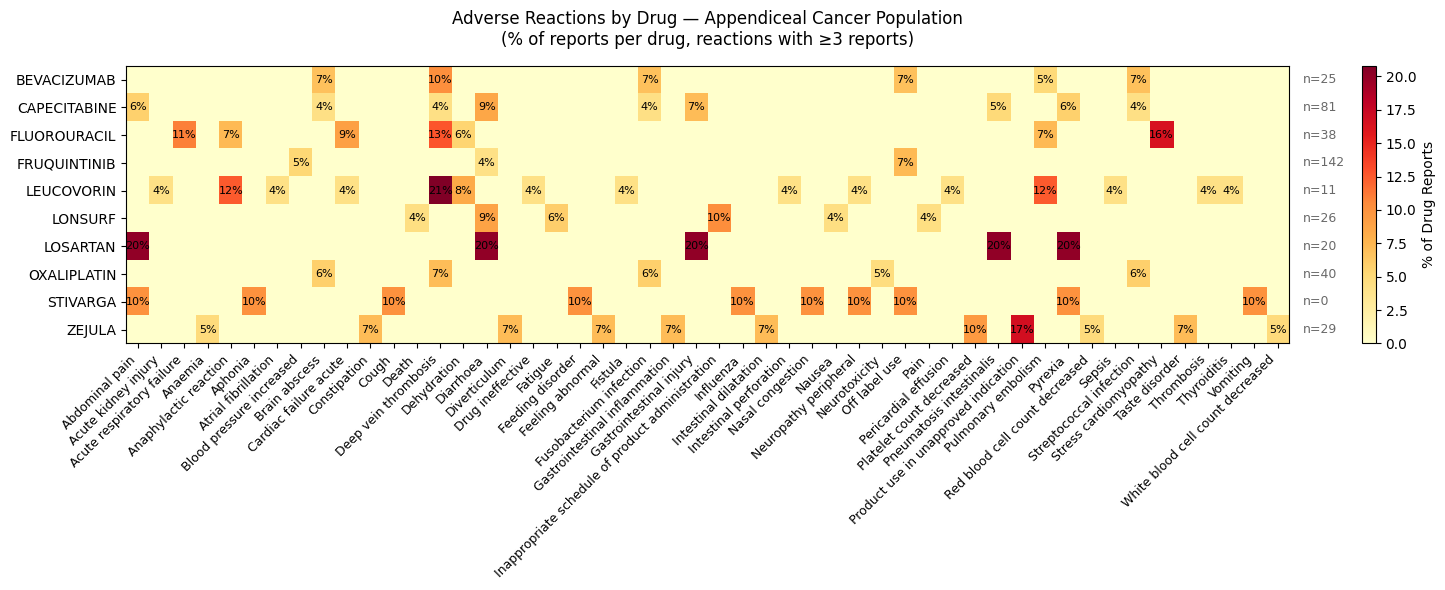

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Get total reports per drug for n= labels
drug_totals = appendiceal_cohort_reactions_pct.groupby("drugname")["reports"].sum()

pivot = appendiceal_cohort_reactions_pct.pivot_table(
    index="drugname",
    columns="reaction",
    values="pct_of_drug_reports",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")

for i, drug in enumerate(pivot.index):
    total = drug_totals.get(drug, 0)
    ax.text(len(pivot.columns) + 0.1, i, f"n={int(total)}",
            va="center", ha="left", fontsize=9, color="dimgray")

ax.set_xlim(-0.5, len(pivot.columns) + 1.5)
plt.colorbar(im, ax=ax, label="% of Drug Reports")
plt.title("Adverse Reactions by Drug - Appendiceal Cancer Population
(% of reports per drug, reactions >4% of drug reports)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()


### Interpretation

The heatmap above shows adverse reactions with â‰¥5 reports stratified by drug across the appendiceal cancer population (~339 reports). Given the small cohort size, counts should be interpreted directionally rather than as definitive signal. Findings are hypothesis-generating rather than confirmatory.

**Key observations:**

**Fruquintinib â€” Off label use (n=14, highest signal)**
Fruquintinib received FDA approval in 2023 for refractory metastatic colorectal cancer. Its appearance as the dominant signal in this appendiceal cohort reflects the limited approved treatment options for rare peritoneal malignancies and clinician willingness to use newer agents off-label in heavily pre-treated patients.

**Deep vein thrombosis â€” cross-drug pattern**
DVT appears across capecitabine, fluorouracil, oxaliplatin, leucovorin, and bevacizumab, the broadest cross-drug signal in this dataset. This reflects cancer-associated thrombosis, a well-documented complication of both the underlying malignancy and chemotherapy in peritoneal disease patients, rather than a drug-specific toxicity.

**Fluorouracil â€” Stress cardiomyopathy (n=9)**
Consistent with the cardiotoxicity signal identified in Module 1's ROR analysis (cardiotoxicity ROR=15.0). The replication of this signal in the appendiceal indication-filtered population strengthens its clinical relevance.

**Capecitabine â€” Diarrhoea (n=12) and GI injury (n=10)**
Expected fluoropyrimidine toxicity. Capecitabine is oral 5-FU and shares the same GI toxicity profile documented extensively in Module 1.

**Brain abscess â€” Capecitabine and Oxaliplatin**
An unusual signal in this cohort. May reflect immunosuppression from chemotherapy or surgical intervention (CRS/HIPEC) creating vulnerability to opportunistic CNS infection. Warrants cautious interpretation given small sample size.

> **Data sparsity caveat:** This cohort contains ~339 reports among the smallest analyzable populations in this project. All findings should be interpreted as directional signals consistent with known clinical patterns rather than statistically validated conclusions.
